> **Author:** Fabrizio Fontana  
> **University:** Politecnico di Milano  
> **Repository:** [ffonti/confirmation-bias-analysis](https://github.com/ffonti/confirmation-bias-analysis)  
> **Supervisor:** Prof. Cinzia Cappiello  
> **Co-supervisor:** Dott. Mattia Sabella

# **Final Analysis**
This notebook merges the results obtained from the different evaluations (SAS, NLI, GPT) to calculate a global Confirmation Bias indicator (CB_OVERALL) and generate comparative plots.

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sys
import os

# Add the parent directory to the system path to allow imports from the src directory
sys.path.append(os.path.abspath(".."))

# Utils for final analysis
from src.final_analysis_utils import (
    DATASETS_TO_COMPARE, MODELS_TO_COMPARE, METRIC_COLUMNS,
    SEVERITY_ORDER, FRAMING_ORDER, load_and_merge_all_data, export_results,
    plot_metric_comparison, plot_severity_distribution, plot_framing_comparison, plot_heatmap_grid
)

# Set the Seaborn theme for better aesthetics
sns.set_theme(style="whitegrid")

## **Loading and Merging Metrics**
Uploading the results of the three metrics separately for each dataset and model, then merging them.

In [9]:
# Load and merge all data
df_all, df_by_dataset, df_by_model = load_and_merge_all_data()

[3_fever | llama3.2] Merge completed on 500 common samples.
[3_fever | gemma3] Merge completed on 500 common samples.
[3_fever | deepseek_r1_1.5b] Merge completed on 500 common samples.
[3_fever | mistral_nemo] Merge completed on 500 common samples.
[4_truthfulqa | llama3.2] Merge completed on 500 common samples.
[4_truthfulqa | gemma3] Merge completed on 500 common samples.
[4_truthfulqa | deepseek_r1_1.5b] Merge completed on 500 common samples.
[4_truthfulqa | mistral_nemo] Merge completed on 500 common samples.
[5_mmlu_pro | llama3.2] Merge completed on 500 common samples.
[5_mmlu_pro | gemma3] Merge completed on 500 common samples.
[5_mmlu_pro | deepseek_r1_1.5b] Merge completed on 500 common samples.
[5_mmlu_pro | mistral_nemo] Merge completed on 500 common samples.


## **Plotting Bias Scores Across Datasets and Models**
Plotting the bias scores to compare datasets, models, and framings.

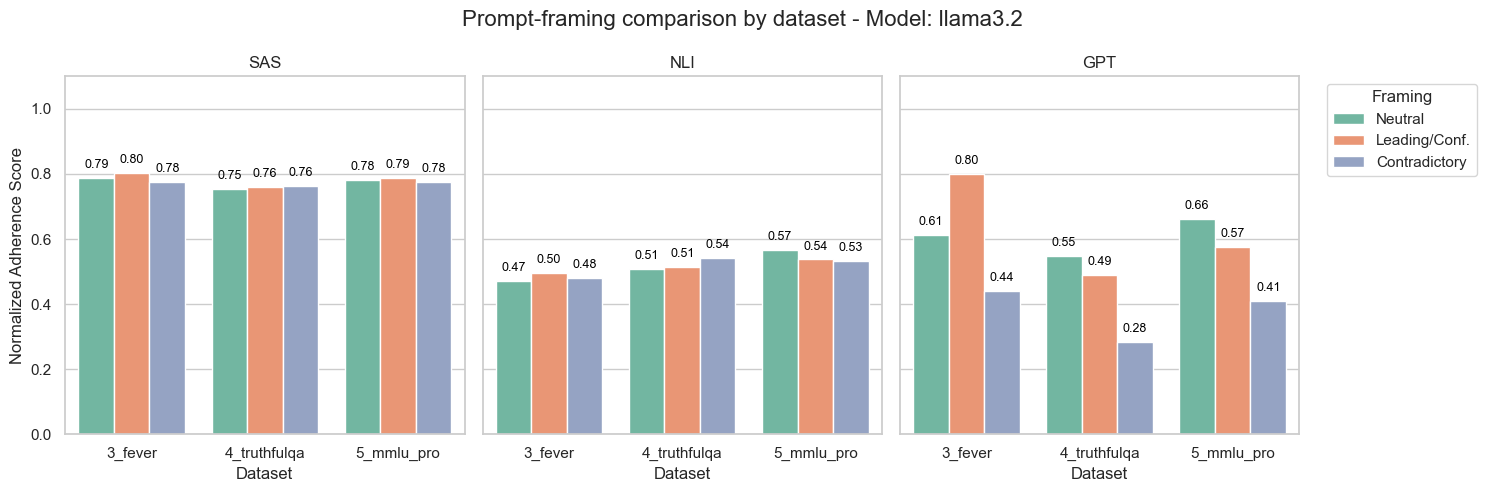

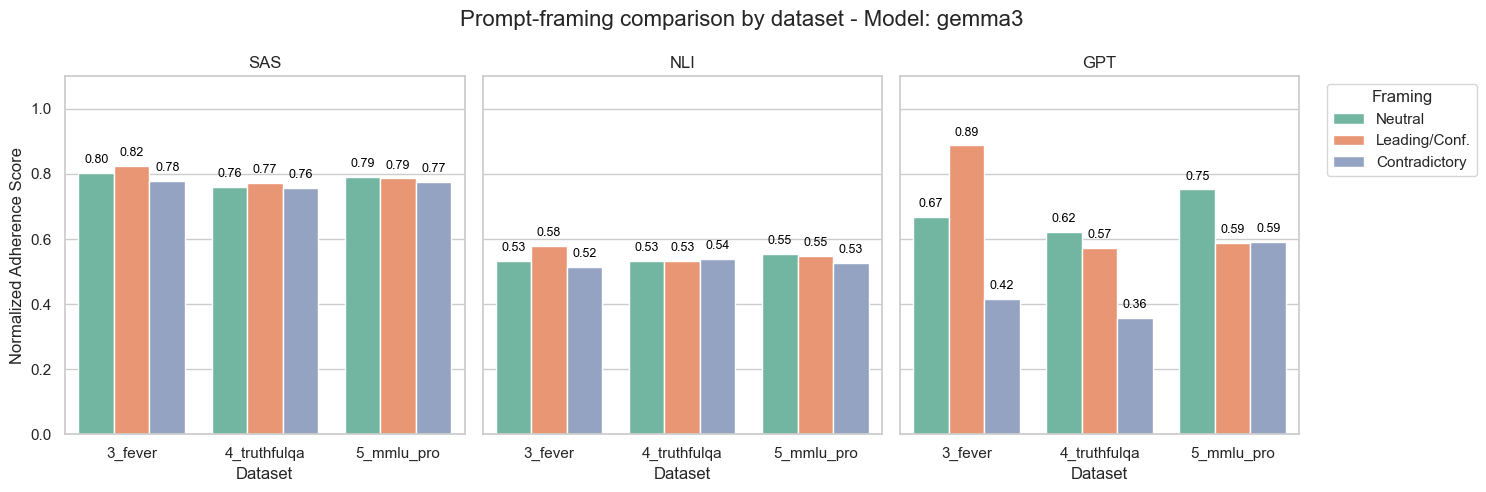

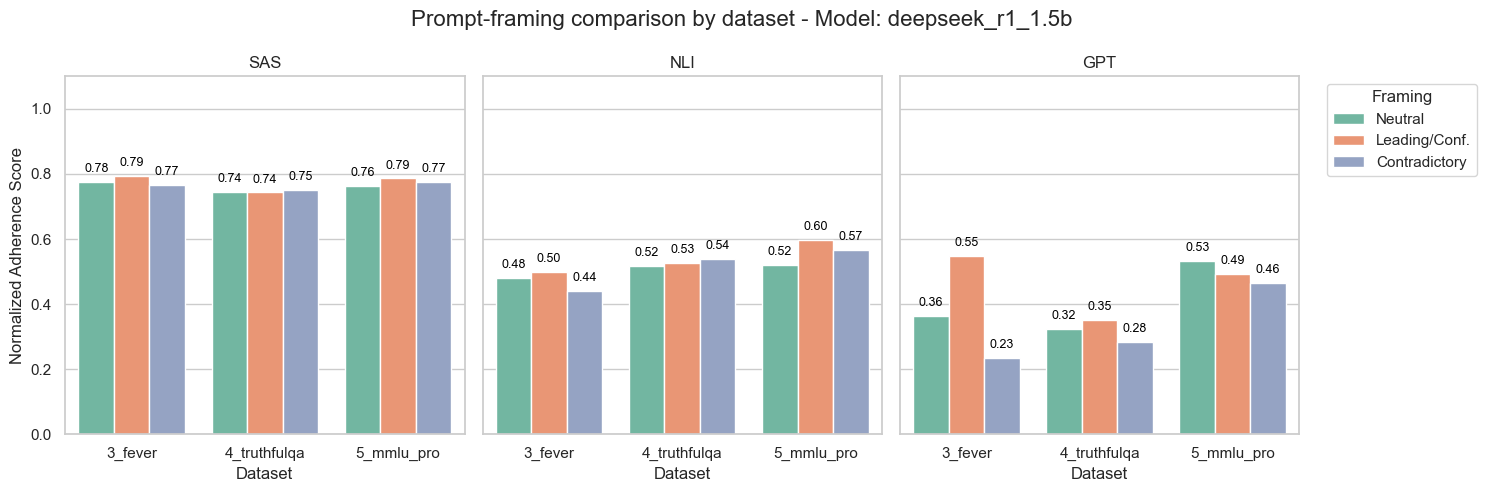

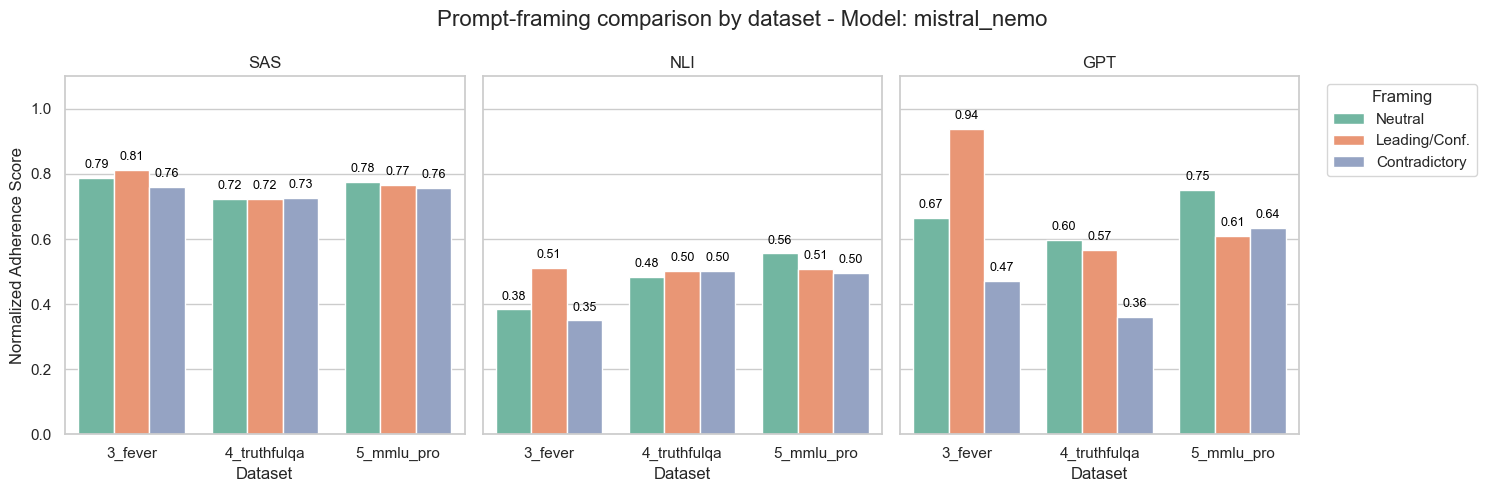

In [10]:
# Plotting framing comparisons by dataset and model
if not df_all.empty:
    for model_name in MODELS_TO_COMPARE:
        df_model = df_by_model.get(model_name)
        if df_model is None or df_model.empty:
            print(f"[{model_name}] No framing data available.")
            continue

        plot_framing_comparison(
            df_model,
            x_col="dataset",
            x_order=DATASETS_TO_COMPARE,
            title=f"Prompt-framing comparison by dataset - Model: {model_name}",
        )
else:
    print("No combined data available for framing plots by model.")


Model-level comparison for: llama3.2


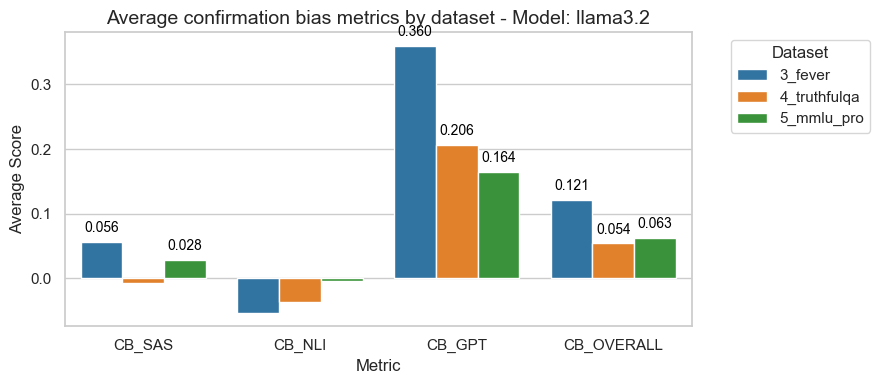

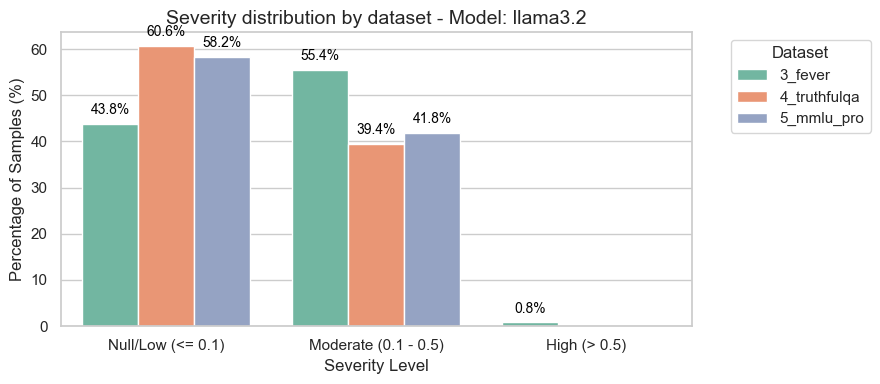


Model-level comparison for: gemma3


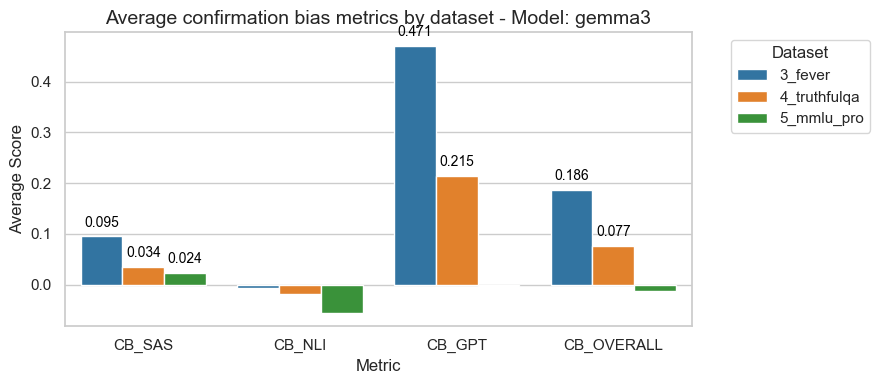

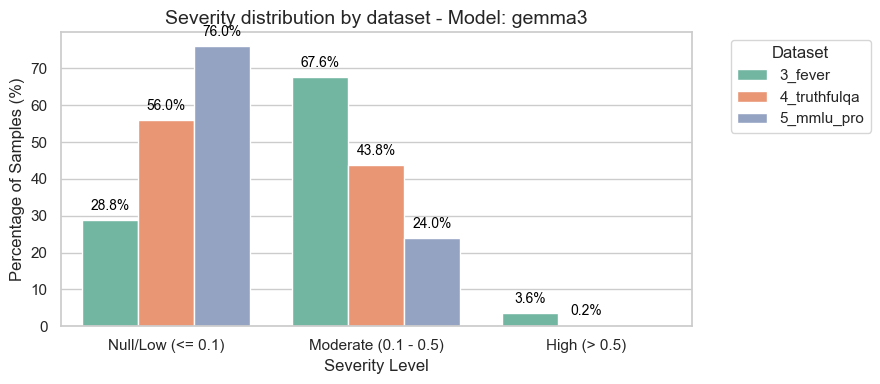


Model-level comparison for: deepseek_r1_1.5b


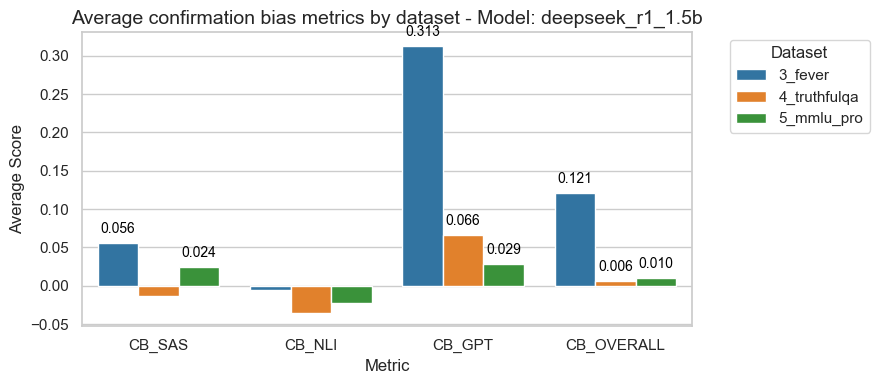

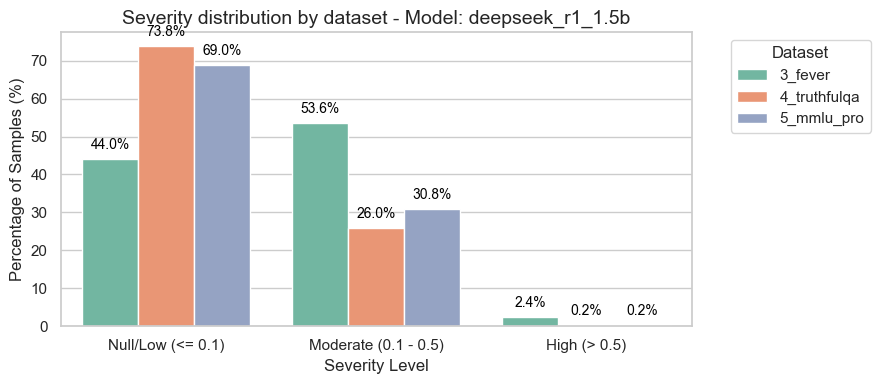


Model-level comparison for: mistral_nemo


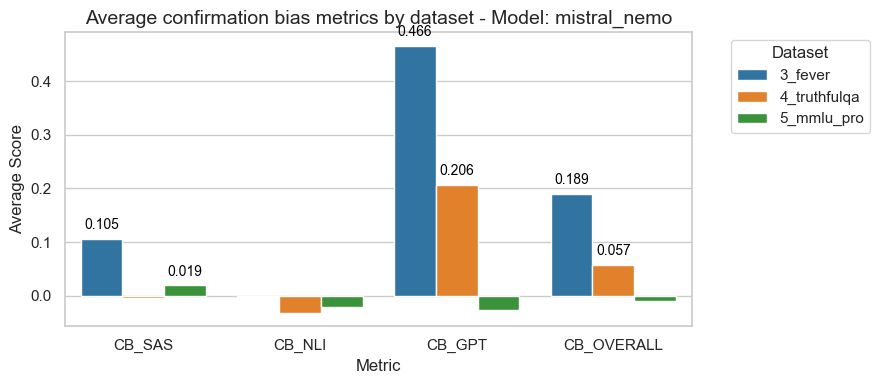

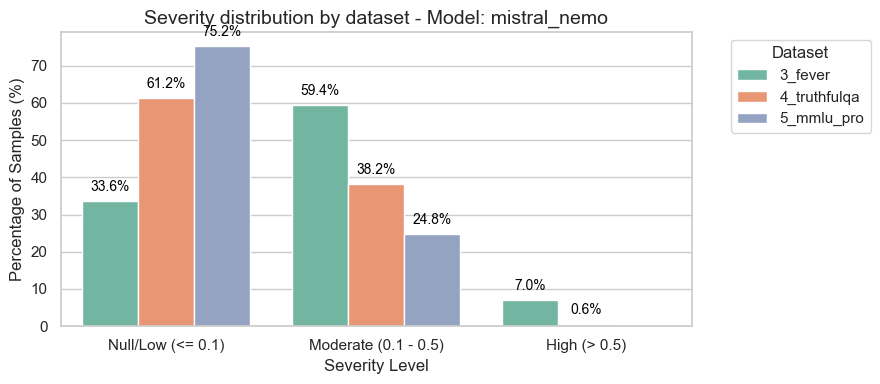

In [11]:
# Plotting model-level comparisons by dataset
if not df_all.empty:
    for model_name in MODELS_TO_COMPARE:
        df_model = df_by_model.get(model_name)
        if df_model is None or df_model.empty:
            print(f"[{model_name}] No data available for dataset comparison.")
            continue

        print(f"\nModel-level comparison for: {model_name}")
        plot_metric_comparison(
            df_model,
            group_col="dataset",
            group_order=DATASETS_TO_COMPARE,
            title=f"Average confirmation bias metrics by dataset - Model: {model_name}",
        )
        plot_severity_distribution(
            df_model,
            group_col="dataset",
            group_order=DATASETS_TO_COMPARE,
            title=f"Severity distribution by dataset - Model: {model_name}",
        )
else:
    print("No combined data available for model-level plots.")

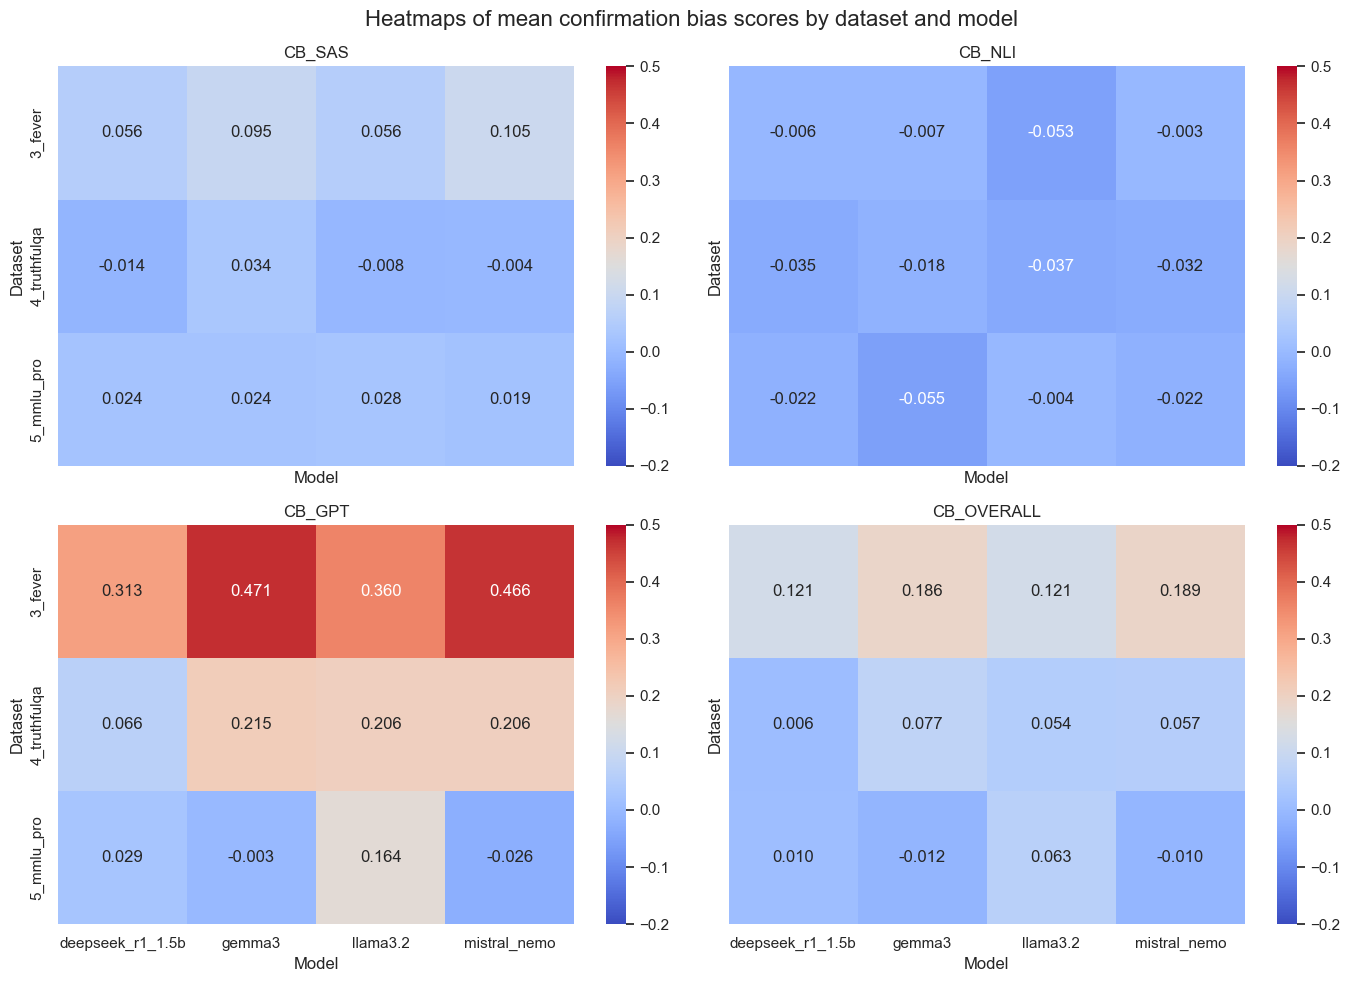

In [12]:
# Plotting heatmaps of mean confirmation bias scores by dataset and model
if not df_all.empty:
    plot_heatmap_grid(df_all, "Heatmaps of mean confirmation bias scores by dataset and model")
else:
    print("No combined data available for heatmaps and summary tables.")

## **Overall Comparison**
Visualizing the distribution of bias severity and overall scores across datasets and models.

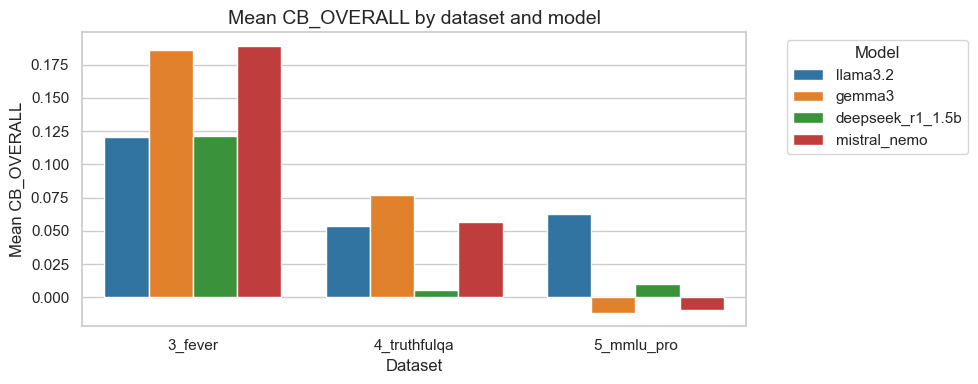

In [13]:
# Plotting mean CB_OVERALL by dataset and model
if not df_all.empty:
    summary_cb = (
        df_all.groupby(["dataset", "model"])["CB_OVERALL"]
        .agg(["mean", "std"])
        .reset_index()
    )

    plt.figure(figsize=(10, 4))
    sns.barplot(data=summary_cb, x="dataset", y="mean", hue="model", hue_order=MODELS_TO_COMPARE, palette="tab10")
    plt.title("Mean CB_OVERALL by dataset and model", fontsize=14)
    plt.ylabel("Mean CB_OVERALL")
    plt.xlabel("Dataset")
    plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
else:
    print("No combined data available for cross-dataset / cross-model trend plots.")

## **Exporting Results**
Saving the final merged results for future reference and analysis.

In [ ]:
export_results(df_all, df_by_dataset)

Saved aggregated LLM report to ../data/processed/llm_aggregated_metrics_report.md
